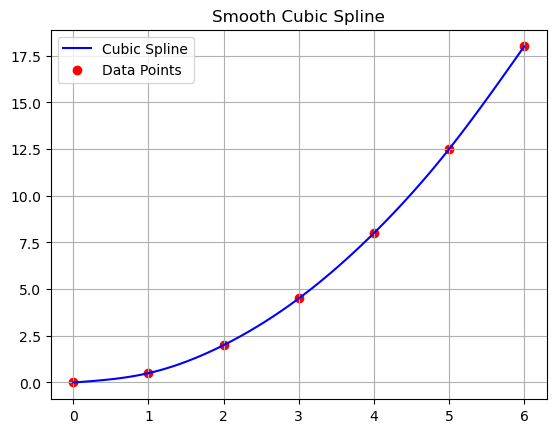

The second derivative values (M) are: [0, 1.2692307692307692, 0.9230769230769231, 1.0384615384615383, 0.923076923076923, 1.2692307692307692, 0]


In [1]:
import matplotlib.pyplot as plt

x = [0, 1, 2, 3, 4, 5, 6]
y = [0, 0.5, 2.0, 4.5, 8.0, 12.5, 18.0]

h = []
for i in range(len(x) - 1):
    h.append(x[i+1] - x[i])
    
n = len(x) - 2  # asked ChatGPT to help with un hard coding arrays

a = [1] * (n - 1)
b = [4] * n
c = [1] * (n - 1)
d = []
for i in range(1, len(y) - 1):
    value = 6 * (y[i+1] - 2*y[i] + y[i-1])
    d.append(value)

n = len(d)
c_prime = [0] * n
d_prime = [0] * n

c_prime[0] = c[0] / b[0]
d_prime[0] = d[0] / b[0]
for i in range(1, n - 1):
    c_prime[i] = c[i] / (b[i] - a[i-1] * c_prime[i-1])

for i in range(1, n):
    denominator = b[i] - a[i-1] * c_prime[i-1]
    d_prime[i] = (d[i] - a[i-1] * d_prime[i-1]) / denominator

M_interior = [0] * n
M_interior[-1] = d_prime[-1]
for i in range(n - 2, -1, -1):
    M_interior[i] = d_prime[i] - c_prime[i] * M_interior[i+1]

M = [0] + M_interior + [0]

def evaluate_spline(x_eval):
    idx = 0
    for i in range(len(x) - 1):
        if x[i] <= x_eval <= x[i+1]:
            idx = i
            break
            
    hi = h[idx]
    A = (x[idx+1] - x_eval) / hi
    B = (x_eval - x[idx]) / hi
    term1 = (M[idx] * (A**3 - A) * hi**2) / 6
    term2 = (M[idx+1] * (B**3 - B) * hi**2) / 6
    term3 = A * y[idx]
    term4 = B * y[idx+1]
    
    return term1 + term2 + term3 + term4
    
x_smooth = []
y_smooth = []
steps = 100
for i in range(steps + 1):
    curr_x = x[0] + (i * (x[-1] - x[0]) / steps)
    x_smooth.append(curr_x)
    y_smooth.append(evaluate_spline(curr_x))

plt.plot(x_smooth, y_smooth, label='Cubic Spline', color='blue')
plt.scatter(x, y, color='red', label='Data Points')
plt.title("Smooth Cubic Spline")
plt.legend()
plt.grid(True)
plt.show()
print("The second derivative values (M) are:", M)